Analisi Diffusione COVID-19
Il committente richiede di avere un report su casi e vaccinazioni in diverse aree del mondo; a tal fine, richiede di utilizzare i dati raccolti e curati da Our World in Data, all'indirizzo https://github.com/owid/covid-19-data/tree/master/public/data dove si trovano le informazioni relative. In particolare, il dataset si può scaricare dalla piattaforma o all'indirizzo
https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv



In [1]:
import pandas as pd

In [2]:
#carico il file CSV
url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"
df = pd.read_csv(url)

1.	Si richiede di verificare le dimensioni del dataset e i relativi metadati

In [3]:
#controllo numero di righe e colonne
df.shape

(429435, 67)

In [4]:
#controllo indice colonne
df.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [5]:
#info su metadati
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [6]:
#estraggo le prime 5 righe del DataFrame
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


2.	Si chiede di trovare, per ogni continente:

**a. il numero di casi fin dall'inizio della pandemia**


In [7]:
numero_casi_continenti = df.groupby("continent")["new_cases"].sum()
print(numero_casi_continenti)

continent
Africa            13146831.0
Asia             301564180.0
Europe           252916868.0
North America    124492698.0
Oceania           15003468.0
South America     68811012.0
Name: new_cases, dtype: float64


b. la percentuale rispetto al totale mondiale del numero di casi

In [8]:
#calcolo la somma dei casi di ogni continente
totale_mondiale = numero_casi_continenti.sum()

In [9]:
#calcolo la percentuale dividendo il totale di casi per continente con il totale dei casi a livello mondiale e moltiplico *100
percentuale = (numero_casi_continenti / totale_mondiale)*100

In [10]:
numero_casi_continenti = df.groupby("continent")["new_cases"].sum()

#calcolo la somma dei casi di ogni continente
totale_mondiale = numero_casi_continenti.sum()

#calcolo la percentuale dividendo il totale di casi per continente con il totale dei casi a livello mondiale e moltiplico *100.
#Uso .round per arrotondare le percentuali
percentuale = ((numero_casi_continenti / totale_mondiale) * 100).round(2)

#creo un DataFrame per la visualizzazione dei dati
vista_dati = pd.DataFrame({
    "Totale casi": numero_casi_continenti,
    "% su TOT Mondiale": percentuale
})

vista_dati

,Totale casi,% su TOT Mondiale
continent,,
Africa,13146831.0,1.69
Asia,301564180.0,38.86
Europe,252916868.0,32.60
North America,124492698.0,16.04
Oceania,15003468.0,1.93
South America,68811012.0,8.87


Selezionare i dati relativi all'Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni

In [11]:
# conversione della colonna date in formato datetime
df["date"] = pd.to_datetime(df["date"])

In [12]:
# selezione dati Italia del 2022
italia_2022 = df[
    (df["location"] == "Italy") &
    (df["date"].dt.year == 2022)
]

In [13]:
# filtro dei giorni che non hanno misurazioni sui nuovi casi
italia_2022 = italia_2022[italia_2022["new_cases"].notna()]

In [14]:
italia_2022.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
186002,ITA,Europe,Italy,2022-01-01,5622431.0,0.0,36797.00,136530.0,0.0,140.86,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186003,ITA,Europe,Italy,2022-01-02,6267035.0,644604.0,92086.29,137513.0,983.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,168226.3,12.99,8.06,2849.48
186004,ITA,Europe,Italy,2022-01-03,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186005,ITA,Europe,Italy,2022-01-04,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186006,ITA,Europe,Italy,2022-01-05,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN


mostrare con dei grafici adeguati:
a. l'evoluzione del casi totali dall'inizio alla fine dell'anno


<Axes: title={'center': 'Evoluzione dei casi totali in Italia nel 2022'}, xlabel='date'>

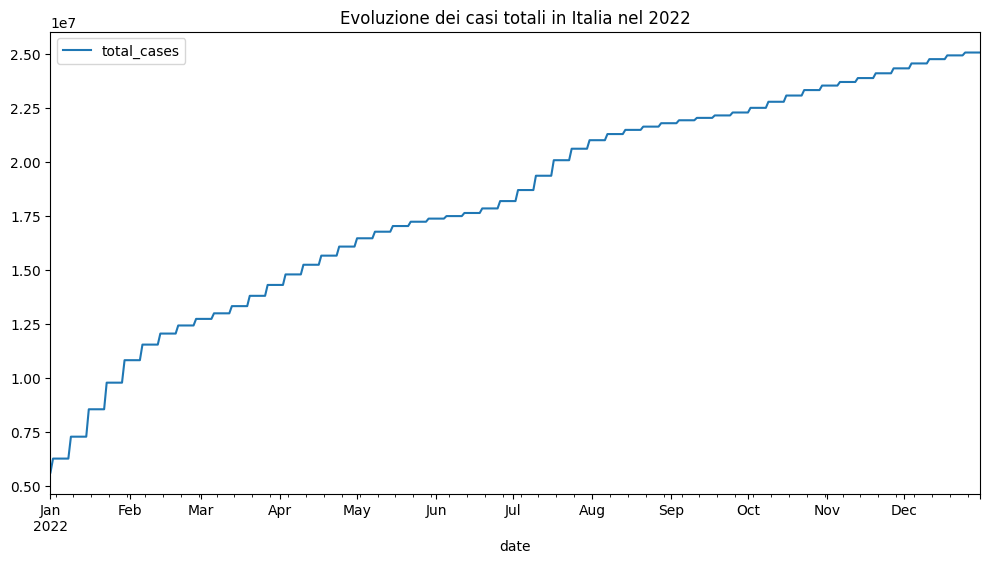

In [15]:
italia_2022.plot(
    x="date",
    y="total_cases",
    figsize=(12,6),
    title="Evoluzione dei casi totali in Italia nel 2022"
)

B.Mostrare con un grafico il numero di nuovi casi rispetto alla data.

<Axes: title={'center': 'Nuovi casi in Italia nel 2022'}, xlabel='date'>

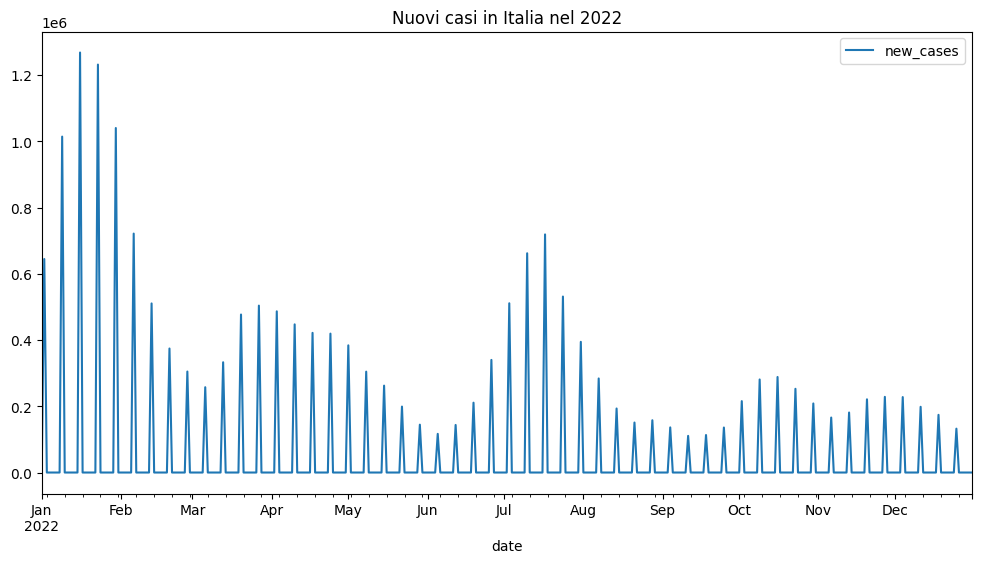

In [16]:
italia_2022.plot(
    x="date",
    y="new_cases",
    figsize=(12,6),
    title="Nuovi casi in Italia nel 2022"
)

In [17]:
#seleziono i dati di Italia, Germania e Francia da maggio 2022 ad aprile 2023
df["date"] = pd.to_datetime(df["date"])

paesi_icu = df[
    (df["location"] == "Italy") |
    (df["location"] == "Germany") |
    (df["location"] == "France")
]

paesi_icu = paesi_icu[
    (paesi_icu["date"] >= "2022-05-01") &
    (paesi_icu["date"] <= "2023-04-30")
]

<Axes: title={'center': 'icu_patients'}, xlabel='location'>

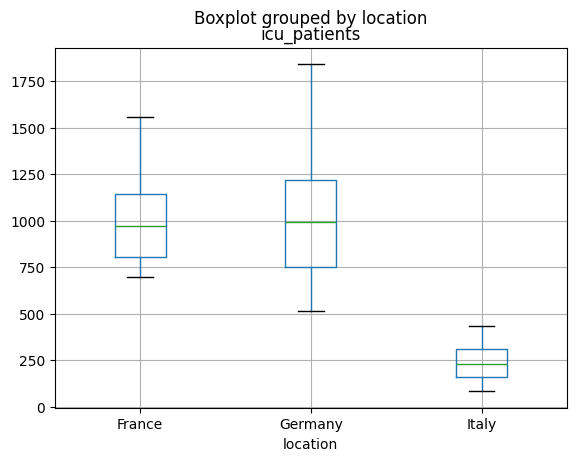

In [18]:
#boxplot dei pazienti in terapia
paesi_icu.boxplot(column="icu_patients", by="location")

In [ ]:
# Il grafico mostra un andamento non lineare dei pazienti in terapia intensiva. Germania e Francia hanno avuto numeri di pazienti in terapia intensiva molto più alti rispetto all’Italia.
#In particolare, la mediana della Germania è leggermente più alta di quella della Francia, mentre l’Italia presenta valori decisamente inferiori.

5.	Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021:
a. mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospitalizzati per ognuna (colonna hosp_patients)


In [19]:
#seleziono i dati di Italia, Germania, Francia e Spagna relativi al 2021
df["date"] = pd.to_datetime(df["date"])

paesi_hosp = df[
    (df["location"] == "Italy") |
    (df["location"] == "Germany") |
    (df["location"] == "France") |
    (df["location"] == "Spain")
]

paesi_hosp_2021 = paesi_hosp[
    (paesi_hosp["date"] >= "2021-01-01") &
    (paesi_hosp["date"] <= "2021-12-31")
]

A. mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospitalizzati per ognuna (colonna hosp_patients)

In [20]:
#sommo i pazienti ospedalizzati per ogni nazione
somma_hosp = paesi_hosp_2021.groupby("location")["hosp_patients"].sum()

print(somma_hosp)

location
France     6008717.0
Germany          0.0
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64


In [21]:
#Uso questi tre comandi per analizzare meglio la colonna hosp_patients nei vari Paesi.
#Il primo calcola la somma dei pazienti ospitalizzati, il secondo mostra quanti dati validi sono presenti, mentre il terzo conta i valori nulli.
#Questo controllo è utile per capire se eventuali risultati anomali, come una somma pari a zero, dipendano da dati reali oppure dalla mancanza di osservazioni.

print(paesi_hosp_2021.groupby("location")["hosp_patients"].sum())
print(paesi_hosp_2021.groupby("location")["hosp_patients"].count())
print(paesi_hosp_2021.groupby("location")["hosp_patients"].apply(lambda x: x.isna().sum()))

location
France     6008717.0
Germany          0.0
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64
location
France     365
Germany      0
Italy      365
Spain      365
Name: hosp_patients, dtype: int64
location
France       0
Germany    365
Italy        0
Spain        0
Name: hosp_patients, dtype: int64


In [22]:
print(paesi_hosp_2021.groupby("location")["hosp_patients"].sum(min_count=1))
print(paesi_hosp_2021.groupby("location")["hosp_patients"].count())
print(paesi_hosp_2021.groupby("location")["hosp_patients"].apply(lambda x: x.isna().sum()))

location
France     6008717.0
Germany          NaN
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64
location
France     365
Germany      0
Italy      365
Spain      365
Name: hosp_patients, dtype: int64
location
France       0
Germany    365
Italy        0
Spain        0
Name: hosp_patients, dtype: int64


In [ ]:
#Ho utilizzato sum(min_count=1) perché la funzione sum(), in presenza di soli valori nulli, restituisce comunque 0.
#Questo però può portare a un’interpretazione sbagliata del risultato, perché quel valore non indica necessariamente che i pazienti ospitalizzati siano stati zero, ma potrebbe semplicemente significare che i dati non sono disponibili.
#Con il parametro min_count=1, invece, la somma viene calcolata solo se è presente almeno un valore valido; in caso contrario, il risultato rimane NaN.
#In questo modo è possibile distinguere correttamente tra un valore realmente nullo e un dato mancante.

<Axes: xlabel='location'>

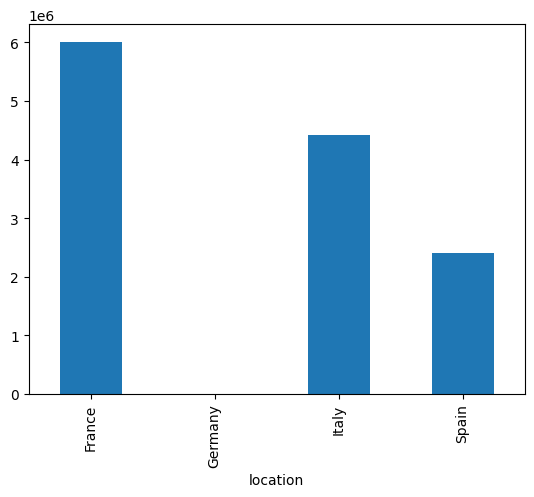

In [23]:
#creo un grafico per la visualizzazione dei dati
somma_hosp.plot(kind="bar")

In [24]:
#Faccio degli ulteriori controlli
print(paesi_hosp_2021["hosp_patients"].isna().sum())

365


In [25]:
null_per_paese = paesi_hosp_2021.groupby("location")["hosp_patients"].apply(lambda x: x.isna().sum())

print(null_per_paese)

location
France       0
Germany    365
Italy        0
Spain        0
Name: hosp_patients, dtype: int64


b. se ci sono dati nulli; con un breve commento scrivere se può essere possibile gestirli tramite sostituzione o meno

In [ ]:
#La presenza di dati nulli per la Germania può essere motivata dal fatto che il dataset di Our World in Data non dispone,
#per quel periodo e per quella variabile, di valori ufficiali completi o compatibili.
#Per questo motivo, il valore nullo indica un dato assente e non un numero di pazienti pari a zero perciò non sostituibili.